# Infectivity Per Mutation
Regress infectivitty results of constructs over mutations in those constructs to get mutation-level constribution to infectivity.

In [1]:
import pandas as pd
import torch
import pickle
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE
import numpy as np

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
import matplotlib.pyplot as plt
import seaborn as sns
# from adjustText import adjust_text

/Users/kotzen/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pyro.set_rng_seed(0)

d = torch.float32
torch.set_default_dtype(d)

run_MCMC = True

## Read in data

In [3]:
# Infectivity
data_dir = 'data/Supp_Material/'
filename = 'Supp_TableS4_Infectivity_Data.csv'
cols=['Name', 'base_norm_1', 'base_norm_2', 'base_norm_3', 'base_norm_avg']
infectivity = pd.read_csv(data_dir+filename, usecols=cols)
infectivity['Name'] = infectivity['Name'].apply(lambda x: x.capitalize() if x.islower() else x)
infectivity = infectivity.dropna()
inf_constructs = infectivity['Name'].unique()
infectivity.head()

,Name,base_norm_1,base_norm_2,base_norm_3,base_norm_avg
0,WuD,0.789729,0.671577,0.943458,0.801588
1,WuG,0.878043,1.327016,0.794941,1.000000
2,Alpha,1.906647,2.548808,2.590958,2.348805
3,Beta,1.912810,1.709156,1.727650,1.783205
4,Gamma,2.473592,2.979554,2.126245,2.526463


In [4]:
# Mutations
data_dir = 'data/Supp_Material/'
filename = 'construct_mutations.csv'   # 'Supp_TableS3_Construct_Summary.csv'
cols = ['Name', 'Designed mutations', 'base_voc']   # ['Name', 'Designed mutations']
mutations = pd.read_csv(data_dir+filename, usecols=cols)
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['Designed mutations'] = mutations['Designed mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list
mutations['Designed mutations'] = mutations['Designed mutations'].apply(lambda x: None if x=='--' else x)   # replace '--' with None

mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WuD', 'Designed mutations':None}])])

mut_constructs = mutations['Name'].unique()
mutations.head()

,Name,base_voc,Designed mutations
0,WuG,WuG,None
1,Alpha,WuG,None
2,Beta,WuG,None
3,Gamma,WuG,None
4,WuG-4a,WuG,"T76I,M153S,Y473F,Q493R"


In [5]:
print('Disconnects:')
for n in set(inf_constructs) - set(mut_constructs):
    print(f'\tInfectivity but no mutations: {n}')
for n in set(mut_constructs) - set(inf_constructs):
    print(f'\tMutations but no infectivity: {n}')

Disconnects:
	Infectivity but no mutations: BA.4/5-2b
	Infectivity but no mutations: BA.4/5
	Infectivity but no mutations: BA.5-2a
	Mutations but no infectivity: BA.5


In [6]:
df = infectivity.merge(mutations, on='Name', how='inner')

df = df[~df['Designed mutations'].isna()]   # only keep designed constructs with designed mutations

# Give base ID
df['base_voc ID'] = df['base_voc'].map({base:i for i, base in enumerate(df['base_voc'].unique())})


print(f'{len(df)} infectivity results:')
df.head()

70 infectivity results:


,Name,base_norm_1,base_norm_2,base_norm_3,base_norm_avg,base_voc,Designed mutations,base_voc ID
11,WuG-4a,1.183455,1.116201,1.158202,1.152620,WuG,"T76I,M153S,Y473F,Q493R",0
12,WuG-5a,0.865055,0.846976,0.875239,0.862424,WuG,"T76I,M153S,Y473F,N481T,Q493R",0
19,BA.2.12.1-2c,1.047152,0.945003,0.971924,0.988026,BA.2.12.1,"R346T,S494R",1
20,BA.2.12.1-2c,0.353821,0.358774,0.362135,0.358243,BA.2.12.1,"R346T,S494R",1
21,BA.2.12.1-4a,0.431526,0.404510,0.383484,0.406506,BA.2.12.1,"A27L,T76I,M153S,Y473F",1


## QA Data

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_5236/703847863.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



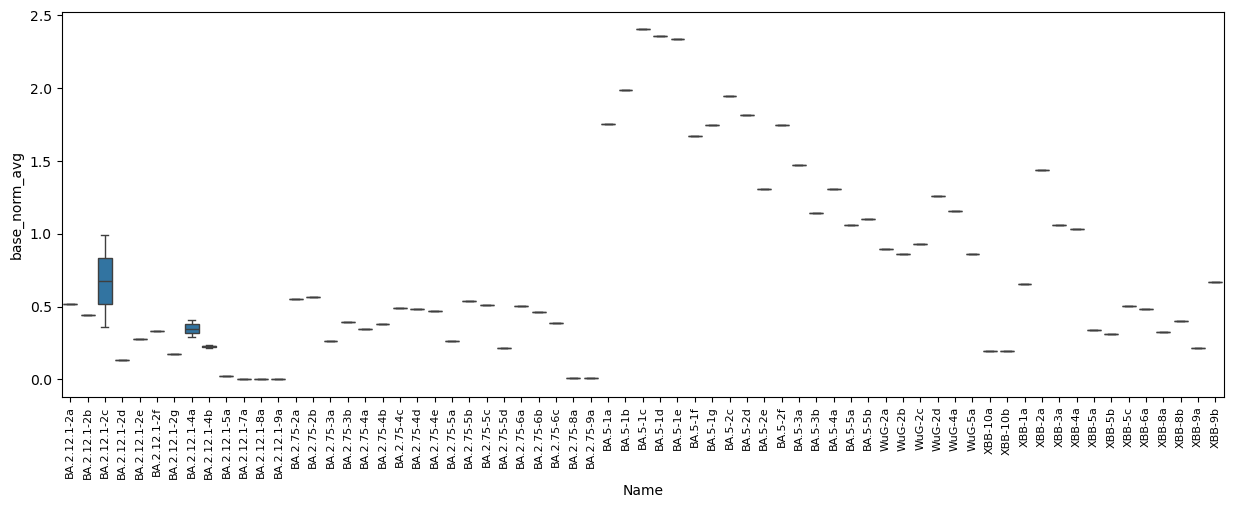

In [7]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(x='Name',
            y='base_norm_avg',
            data=df.sort_values(by='Name'),
            ax=ax)
ax.set_xticklabels(df.sort_values(by='Name')['Name'].unique(), rotation=90, fontsize=8);

In [8]:
# user_flagged_outliers = input('Which constructs should be removed as outliers?\n').split(', ')
# df = df[~df['Name'].isin(user_flagged_outliers)]

## Prepare model

In [9]:
def one_hot(mutations: pd.Series):
    features = list(set(','.join(filter(None, mutations.tolist())).split(',')))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return torch.tensor(onehot, dtype=d), features

In [10]:
# Infectivity Model
def model(X,Y):
    # Y might have one or multiple obervations for each construct -
    # let's make sure the shape is consistent
    if len(Y.shape)==1:
        Y = Y.unsqueeze(-1)
    
    # Set hyperparameters
    μ_m = 0.
    σ_m = 1.
    μ_b = 1.
    σ_b = 1.
    
    σ = 0.2   # 1.
    
    # Sample mutation contribution for each mutation
    with pyro.plate("mutations", X.shape[1]):
        m = pyro.sample("m", dist.Normal(μ_m, σ_m))
    
    # Sample baseline
    b = pyro.sample("b", dist.Normal(μ_b, σ_b))
    
    # Predict infectivity
    pred_infectivity = torch.matmul(X,m) + b
    
    # Score observations
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(pred_infectivity, σ), obs=torch.transpose(Y,0,1))

## Fit model

In [11]:
X, features = one_hot(df['Designed mutations'])
Y = torch.tensor(df[['base_norm_1', 'base_norm_2', 'base_norm_3']].values, dtype=d)

In [12]:
model_dir = 'model_infectivity/'
chain_file = 'mcmc_chain.pkl'
features_file = 'mcmc_features.txt'

if run_MCMC:
    nuts_kernel = NUTS(model)

    mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=2000)
    mcmc.run(X, Y)

    posterior_samples = mcmc.get_samples()

    # Save
    with open(model_dir+chain_file, 'wb') as f:
        pickle.dump(posterior_samples, f)

    with open(model_dir+features_file, 'w') as f:
        f.writelines([f+'\n' for f in features])
        
else:
    with open(model_dir+chain_file, 'rb') as f:
        posterior_samples = pickle.load(f)
    
    with open(model_dir+features_file, 'r') as f:
        features = f.read().split('\n')
        features.remove('')

Sample: 100%|█| 4000/4000 [01:57, 34.10it/s, step size=1.58e-01, acc. prob=0.915


## Inspect Traces

In [ ]:
# Show all traces at once
def plot_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(round(num_trace/2), 2, figsize=(14, 7))
    axes = axes.flatten()
    
    for key, ax in zip(samples.keys(),axes):
        trace = samples[key]
        ax.plot(trace.detach().numpy(), linewidth=0.5, alpha=0.5)
        ax.set_title(key)
        # ax.legend(ncol=3, fontsize=5)
        
        fig.tight_layout()
        
    return fig, axes
        
fig, axes = plot_trace(posterior_samples)
fig.savefig('figs/infectivity_traces.png', dpi=150)

In [ ]:
def dropdown_plot(data_dict):
    def setup():
        # Initialize Plotly for Jupyter Notebook
        init_notebook_mode(connected=True)
    def initialize_plot(data_dict):
        # Create a list of names from the dictionary keys
        names = list(data_dict.keys())
        # Create the initial scatter plot
        initial_name = names[0]  # Initial name to display
        initial_data = data_dict[initial_name]

        trace = go.Scatter(
            x=list(range(len(initial_data))),
            y=initial_data,
            mode='markers',
            name=initial_name
        )

        layout = go.Layout(
            title='Convergence of MCMC Traces',
            xaxis=dict(title='Sample'),
            yaxis=dict(title='Value')
        )

        fig = go.Figure(data=[trace], layout=layout)
        return fig

    def dropdown(data_dict, fig):
        # Create the dropdown menu
        updatemenu = []
        buttons = []

        for name in list(data_dict.keys()):
            data = data_dict[name]
            button = {
                'label': name,
                'method': 'update',
                'args': [{'x': [list(range(len(data)))], 'y': [data], 'name': name}]
            }
            buttons.append(button)

        updatemenu = [
            {
                'buttons': buttons,
                'direction': 'down',
                'showactive': True,
                'x': 0,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            }
        ]

        fig.update_layout(showlegend=True, updatemenus=updatemenu)
        return fig

    fig = initialize_plot(data_dict)
    fig = dropdown(data_dict, fig)
    
    return fig

In [27]:
trace_dict = dict()
trace_dict['b'] = posterior_samples['b']
for i in range(posterior_samples['m'].shape[1]):
    trace_dict[f'm_{features[i]}'] = posterior_samples['m'][:,i]

fig = dropdown_plot(trace_dict)
iplot(fig)
fig.write_html('figs/infectivity_mcmc_traces.html')

## Visualize Coefficients

In [ ]:
def preprocess_kde(samples, labels):
    m_samples = samples['m']
    b_samples = samples['b']
    all_samples = torch.cat((m_samples, b_samples.reshape(-1,1)), dim=1)  # put β at the end
    coefficients = labels.copy()
    sort_by = all_samples.mean(dim=0)
    sort_by = sort_by[:-1]  # intercept is the last term in this tensor
    coef_map = {x:i for i, (_,x) in enumerate(sorted(zip(sort_by, labels), reverse=True))}
    # Add intercept term last
    coefficients.append('Baseline (WuD)')
    coef_map['Baseline (WuD)'] = len(coefficients)-1
    return all_samples, coefficients, coef_map

def setup(fig, axes, samples):
    options = {}
    options['scale'] = 1
    options['xlim'] = [-3, 3]
    options['ymax'] = samples.shape[1]
    
    axes[1].spines.right.set_visible(False)
    axes[1].spines.left.set_visible(False)
    axes[1].spines.top.set_visible(False)
    axes[1].set_yticks([])
    axes[1].set_yticklabels([])
    
    axes[0].axis('off')
    axes[2].axis('off')
    
    plt.rcParams['font.family'] = ['Times New Roman']
    return options

def plot_kdes(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'blue'
    linewidth = 0.7
    
    for i, coef in tqdm(enumerate(coefficients)):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        sample_idx = i
        # Fit KDE
        s = samples[:, sample_idx]
        kde = KDE(kernel='gaussian', bandwidth=0.01).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        ax.plot(x, y, 
                color=color, linewidth=linewidth)
        
    ax.set_xlim(xlim)
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Posterior', loc='center')
    
    
def annotate_posterior(ax, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    pos = [ymax - i for i in range(ymax)]
    labels = list(coef_map.keys())
    for y, t in zip(pos, labels):
        ax.text(1, y, t,
                ha='right')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Mutations', loc='right')
    
def annotate_means(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    coefs = list(coef_map.keys())
    for i, c in enumerate(coefficients):
        mean = samples[:,i].mean()
        t = '{:6.2f}'.format(mean)
        y = ymax - coef_map[c]
        ax.text(0, y, t,
                ha='left')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Means', loc='left')
    
def affordances(ax, options):
    ax.vlines(0, 0, options['ymax']+options['scale'],
             color='gray', linewidth=0.5, alpha=0.5)
    ax.vlines(1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.vlines(-1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.text(0, options['ymax']+options['scale'], '0', ha='center', va='bottom', fontsize=6)
    ax.text(1, options['ymax']+options['scale'], '+1', ha='center', va='bottom', fontsize=6)
    ax.text(-1, options['ymax']+options['scale'], '-1', ha='center', va='bottom', fontsize=6)

25it [00:00, 65.64it/s]


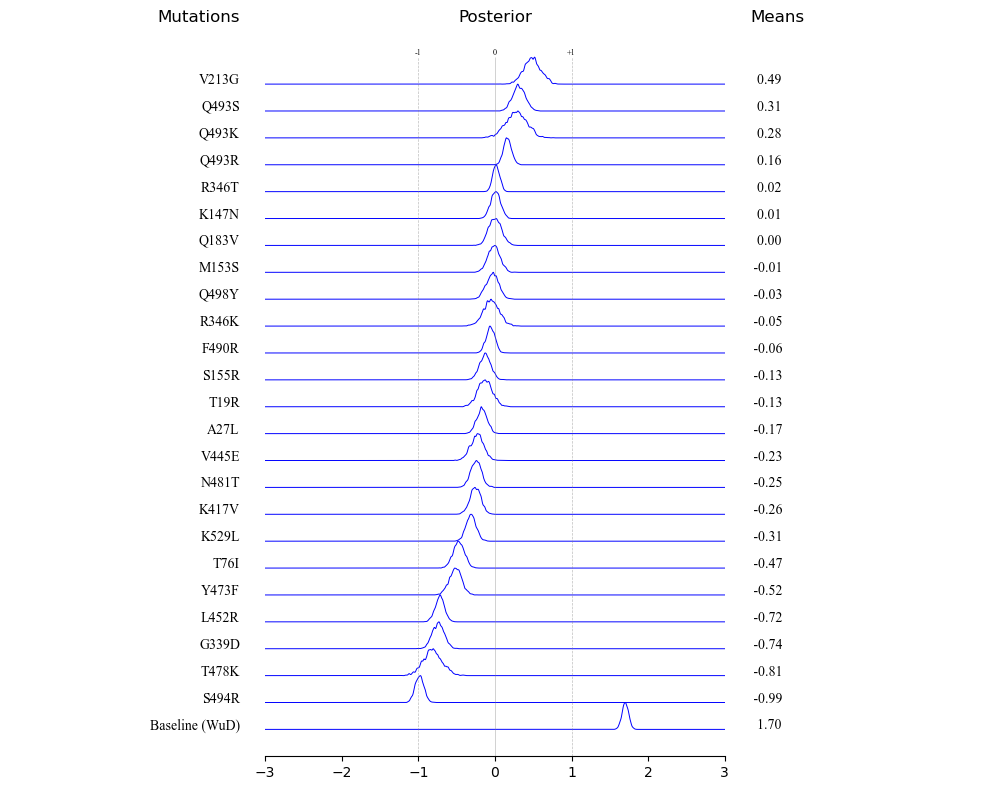

In [17]:
all_samples, coefficients, coefficient_map = preprocess_kde(posterior_samples, features)

fig, axes = plt.subplots(1, 3, figsize=(10, 8), gridspec_kw={'width_ratios': [1, 2, 1]})

options = setup(fig, axes, all_samples)
plot_kdes(axes[1], all_samples, coefficients, coefficient_map, options)
annotate_posterior(axes[0], coefficients, coefficient_map, options)
annotate_means(axes[2], all_samples, coefficients, coefficient_map, options)
affordances(axes[1], options)

fig.tight_layout()
fig.savefig('figs/infectivity_posterior_with_annotations.png', dpi=150)

In [18]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 540]
    
    axes[0].set_xlim(options['xlim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, optoins):
    ax.plot(positions, means, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, coefficients)):
        x = pos
        y = means[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde

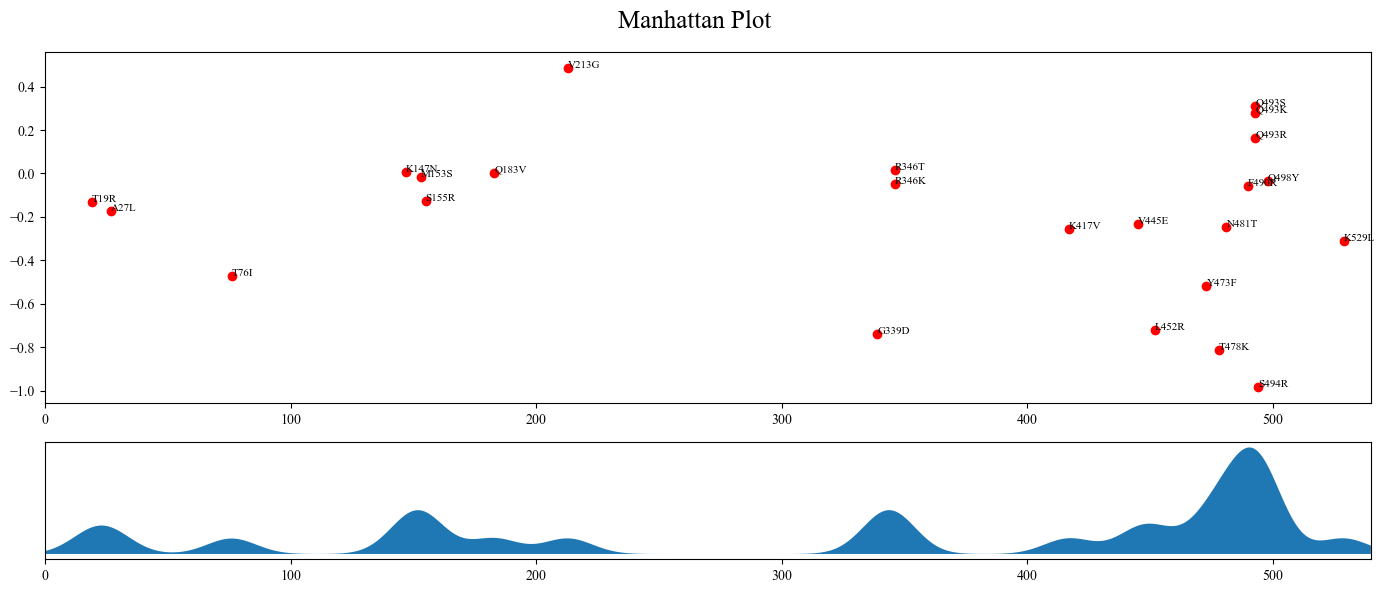

In [19]:
fig, axes, options = setup()

all_means, positions, coefficients = preprocess_manhattan(posterior_samples['m'], features)

kde = plot_density(axes[1], positions, options)

plot_coef(axes[0], all_means, positions, coefficients, options)

fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()

fig.savefig('figs/Infectivity_Manhattan.png', dpi=150)

## Visualize Error

In [20]:
def pred_y(X, m, b):
    return torch.matmul(X,m) + b

def prob_y(X, m, b, σ):
    pred_infectivity = pred_y(X, m, b)
    return torch.exp(dist.Normal(pred_infectivity, σ).log_prob(torch.transpose(Y,0,1)))

Y_pred = pred_y(X, posterior_samples['m'].mean(axis=0), posterior_samples['b'].mean(axis=0))
Y_prob = prob_y(X, posterior_samples['m'].mean(axis=0), posterior_samples['b'].mean(axis=0), 1)

In [37]:
data = pd.DataFrame()
data['base_voc'] = df['base_voc']
data['Observation'] = df[['base_norm_1', 'base_norm_2', 'base_norm_3']].apply(lambda x: x.mean(), axis=1)
data['Prediction'] = Y_pred

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_5236/2020289159.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



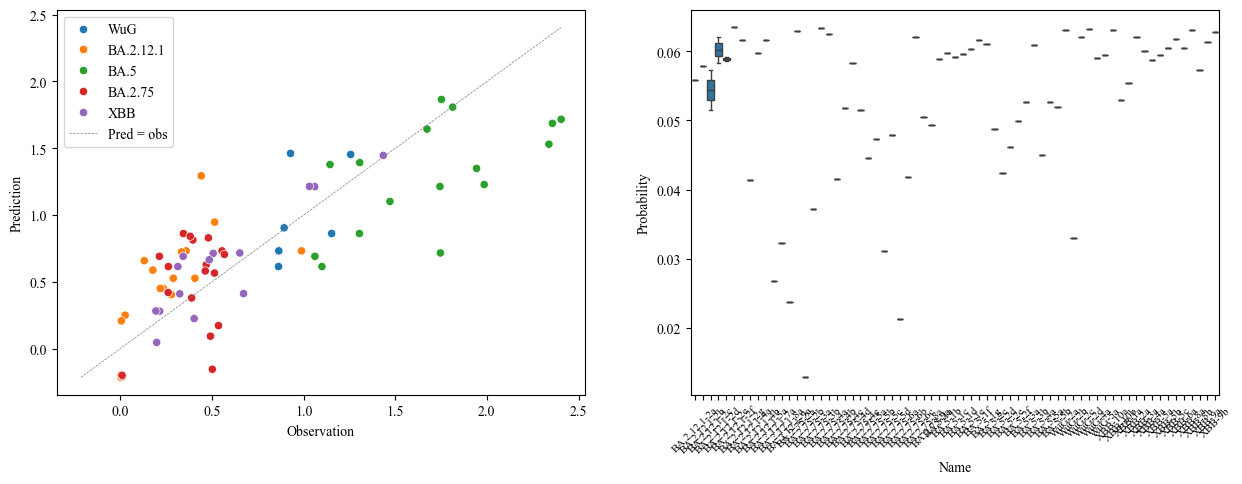

In [38]:
fig, axes = plt.subplots(1,2, figsize=(15,5))


# QQ Plot
ax = axes[0]
# ax.scatter(Y.mean(axis=1), Y_pred, label='Constructs')
sns.scatterplot(x='Observation',
                y='Prediction',
                hue='base_voc',
                data=data,#pd.concat([df, pd.Series(Y_pred)], axis=1).rename(columns={'base_norm_avg':'Observation', 0:'Prediction'}),
                ax=ax
               )
mi, ma = min(torch.cat([Y.mean(axis=1), Y_pred])), max(torch.cat([Y.mean(axis=1), Y_pred])) 
ax.plot([mi, ma], [mi, ma], linestyle='--', linewidth=0.5, color='gray', label='Pred = obs')
ax.legend()
ax.set_xlabel('Observation')
ax.set_ylabel('Prediction')

# Probability
ax = axes[1]
sns.boxplot(x='Name',
            y='Probability',
            data=pd.DataFrame({'Name':df['Name'].values,
                             'Probability':torch.prod(Y_prob, axis=0)}),
            ax=ax)
ax.set_xticklabels(df.sort_values(by='Name')['Name'].unique(), rotation=45, fontsize=8);

## Save Coefficients

In [22]:
# Create a CSV with results
outfile = 'results/mutation_infectivity_effects.csv'
results = pd.DataFrame({'Mutation':features, 'Mean':posterior_samples['m'].mean(dim=0), 'Std':posterior_samples['m'].std(dim=0)}).sort_values(by='Mean', ascending=False).reset_index(drop=True)
results.to_csv(outfile, index=False)

outfile = 'results/baseline_infectivity_effects.csv'
constants = pd.DataFrame([{'Baseline':'WuD', 'Mean':posterior_samples['b'].mean().item(), 'Std':posterior_samples['b'].std().item()}]).sort_values(by='Mean', ascending=False).reset_index(drop=True)
constants.to_csv(outfile, index=False)

print('Top mutations:')
display(results.head())
print('Bottom mutations:')
display(results.tail())

Top mutations:


,Mutation,Mean,Std
0,V213G,0.485780,0.110663
1,Q493S,0.312759,0.082326
2,Q493K,0.277416,0.138239
3,Q493R,0.164296,0.051871
4,R346T,0.015680,0.045326


Bottom mutations:


,Mutation,Mean,Std
19,Y473F,-0.516389,0.080451
20,L452R,-0.720489,0.060575
21,G339D,-0.740484,0.078215
22,T478K,-0.812846,0.126364
23,S494R,-0.985284,0.056334
